# 04 — Predicting berth waiting time at Brazilian container terminals

When a deep-sea container ship arrives off a Brazilian terminal, how long will it wait before it berths? And can a model do better than what a planner already knows from the terminal's recent history?

**Data.** ANTAQ 2025 only. The call-level file exported by notebook 02 (`calls_2025.csv`), plus arrival, berthing and unberthing timestamps from ANTAQ's bulk download (`2025Atracacao.txt`, extracted 17 July 2026). No AIS, no ETAs, no berth windows.

**Scope.** Deep-sea calls at the same 11 terminals used in notebook 02. Terminals where the logged arrival time is effectively the berthing time, and terminals that mostly handle non-container ships, stay out.

In [1]:
# 1 — Setup: paths, libraries and the call-level file exported by notebook 02
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

candidates = [Path.cwd(), *Path.cwd().parents]
BASE = next((p for p in candidates if (p / "data" / "processed").exists()), None)
if BASE is None:
    raise FileNotFoundError(f"data/processed not found from {Path.cwd()} - run the notebook from inside the project folder.")

calls = pd.read_csv(BASE / "data" / "processed" / "calls_2025.csv")
assert calls["call_id"].is_unique
print(BASE.name, calls.shape)
print(calls["navigation"].value_counts().to_string())

ANTAQ_2025_Projeto2 (10007, 21)
navigation
Longo Curso       6580
Cabotagem         2482
Interior           944
Apoio Marítimo       1


In [2]:
# 2 — Call timestamps from ANTAQ's bulk download, checked against the panel export
atr = pd.read_csv(BASE / "data" / "raw" / "antaq_2025_atracacao.txt", sep=";", dtype=str, encoding="utf-8-sig")

cols = {"IDAtracacao": "call_id", "IDBerco": "berth_id",
        "Data Chegada": "ts_arrival", "Data Atracação": "ts_berth",
        "Data Início Operação": "ts_ops_start", "Data Término Operação": "ts_ops_end",
        "Data Desatracação": "ts_unberth"}
atr = atr[list(cols)].rename(columns=cols)
atr["call_id"] = atr["call_id"].astype(int)
for c in [c for c in atr.columns if c.startswith("ts_")]:
    atr[c] = pd.to_datetime(atr[c], format="%d/%m/%Y %H:%M:%S", errors="coerce")
assert atr["call_id"].is_unique

calls_ts = calls.merge(atr, on="call_id", how="left", validate="1:1")
calls_ts["wait_recalc_h"] = (calls_ts["ts_berth"] - calls_ts["ts_arrival"]).dt.total_seconds() / 3600

ok = calls_ts["t_wait_h"].notna() & calls_ts["wait_recalc_h"].notna()
gap = (calls_ts.loc[ok, "wait_recalc_h"] - calls_ts.loc[ok, "t_wait_h"]).abs()
print(f"Calls with arrival timestamp: {calls_ts['ts_arrival'].notna().mean():.2%} of {len(calls_ts)}")
print(f"Recalculated wait vs panel, gap > 0.1h: {(gap > 0.1).sum()} of {ok.sum()} (max {gap.max():.2f}h)")

Calls with arrival timestamp: 99.93% of 10007
Recalculated wait vs panel, gap > 0.1h: 0 of 9915 (max 0.00h)


In [3]:
# 3 — Comparable universe: same terminal and month rules as notebook 02
lc = calls_ts[calls_ts["navigation"] == "Longo Curso"].copy()

prof = lc.groupby("terminal").agg(
    n=("call_id", "size"),
    teu_per_call=("teu", "mean"),
    p50=("t_wait_h", "median"),
    p90=("t_wait_h", lambda s: s.quantile(0.9)),
    share_below_1h=("t_wait_h", lambda s: (s < 1).mean()),
)
prof = prof[prof["n"] >= 100].copy()
prof["arrival_logging"] = (prof["share_below_1h"] > 0.5) | (prof["p90"] / prof["p50"] < 2)
prof["non_container"] = prof["teu_per_call"] < 300
TERMINALS = prof.index[~prof["arrival_logging"] & ~prof["non_container"]].tolist()
TERM_CODE = {t: i for i, t in enumerate(sorted(TERMINALS))}
print(prof.sort_values("n", ascending=False).round(2).to_string(), "\n")

universe = lc[lc["terminal"].isin(TERMINALS)].copy()
print(f"Comparable terminals: {len(TERMINALS)} | {len(universe)/len(lc):.1%} of deep-sea calls, "
      f"{universe['teu'].sum()/lc['teu'].sum():.1%} of TEU")

monthly = universe.groupby(["terminal", "month"]).size().unstack(fill_value=0)
gaps = monthly.lt(0.5 * monthly.median(axis=1), axis=0)
FAILED_MONTHS = [(t, m) for t in gaps.index for m in gaps.columns if gaps.loc[t, m]]
n_before = len(universe)
universe = universe[[(t, m) not in FAILED_MONTHS for t, m in zip(universe["terminal"], universe["month"])]]
print(f"Reporting gaps: {FAILED_MONTHS} -> {n_before - len(universe)} calls dropped | universe: {len(universe)} calls")

                                                       n  teu_per_call    p50    p90  share_below_1h  arrival_logging  non_container
terminal                                                                                                                            
Santos | Cais Da Santos Brasil (Ssz 16) - Privativo  727       2563.15  15.63  71.53            0.13            False          False
Porto Itapoá Terminais Portuários                    692       2090.28   8.30  44.47            0.01            False          False
Santos | Cais Da Btp (Ssz 41) - Privativo            675       2294.92  19.03  77.03            0.00            False          False
Paranaguá | Tcp                                      647       1815.63  19.47  87.76            0.00            False          False
DP World Santos                                      452       2038.28  15.50  59.99            0.00            False          False
Rio Grande | Cais Tecon Rio Grande S.A.              408       1747.1

In [4]:
# 4 — What the panel hides as 'Valor Discrepante'
rows = []
for t, grp in universe.groupby("terminal"):
    masked = grp.loc[grp["t_wait_h_discrepant"], "wait_recalc_h"]
    rows.append({"terminal": t, "n": len(grp), "n_masked": len(masked),
                 "share_masked": len(masked) / len(grp),
                 "max_visible_h": grp["t_wait_h"].max(),
                 "min_masked_h": masked.min() if len(masked) else np.nan,
                 "median_masked_h": masked.median() if len(masked) else np.nan})
diag = pd.DataFrame(rows).set_index("terminal").sort_values("share_masked", ascending=False)
diag["clean_cut"] = np.where(diag["n_masked"] > 0, diag["min_masked_h"] > diag["max_visible_h"], np.nan)
print(diag.round(2).to_string(), "\n")

masked = universe.loc[universe["t_wait_h_discrepant"], "wait_recalc_h"]
bands = pd.cut(masked / 24, bins=[0, 7, 14, 30, 365, np.inf],
               labels=["<=7 days", "7-14", "14-30", "30-365", ">1 year"])
print("Masked values by band:\n", bands.value_counts().sort_index().to_string(), "\n")

early = universe[universe["ts_arrival"] < "2025-01-01"]
print(f"Arrivals logged before 2025: {len(early)}")
print(early["ts_arrival"].dt.to_period("M").value_counts().sort_index().to_string())

                                                       n  n_masked  share_masked  max_visible_h  min_masked_h  median_masked_h  clean_cut
terminal                                                                                                                                 
Porto Itapoá Terminais Portuários                    692        44          0.06          75.40         75.90           102.57        1.0
Portonave - Terminais Portuários de Navegantes       334         6          0.02         117.30        126.40           149.00        1.0
Paranaguá | Tcp                                      644         7          0.01         345.03       8763.28          8767.05        1.0
DP World Santos                                      452         3          0.01         200.55        209.22           368.88        1.0
Terminal Portuário do Pecém                          184         1          0.01         746.28       8757.43          8757.43        1.0
Rio Grande | Cais Tecon Rio Grande

### What 'Valor Discrepante' actually hides

The ANTAQ panel replaces some waiting times with the label "Valor Discrepante". Recomputing them from the raw timestamps shows a clean cut at every terminal that has masked values: the smallest hidden wait is always longer than the longest visible one. In other words, the panel trims the top of each terminal's distribution. It is not only removing errors.

At Itapoá, 6% of calls are hidden, all above 75 hours, with a median of about 100 hours. Those are real long waits, so the P90 figures in notebook 02 should be read as lower bounds, Itapoá's in particular.

Not everything hidden is plausible. Nine values sit at roughly one year, which matches arrivals logged in early 2024 instead of 2025. Those are dropped rather than "fixed", because subtracting a year gives negative waits in some cases.

**Target decision.** Waits are taken from the timestamps, hidden values included, up to 14 days. The same cap applies to visible and recovered values. A liner service that waits more than two weeks usually skips the port. The cap is a judgement call, so section 15 repeats the key test with a 30-day cap.

In [5]:
# 5 — Target: wait from timestamps, hidden values recovered up to a plausibility cap
CAP_H = 14 * 24

def build_target(df, cap_h):
    out = df[df["wait_recalc_h"].notna()].copy()
    out["wait_h"] = out["wait_recalc_h"]
    out["recovered"] = out["t_wait_h_discrepant"]
    year_error = out["ts_arrival"] < "2024-12-01"
    above = (out["wait_h"] > cap_h) & ~year_error
    log = {"year_error": int(year_error.sum()),
           "above_cap_visible": int((above & ~out["recovered"]).sum()),
           "above_cap_recovered": int((above & out["recovered"]).sum())}
    out = out[~year_error & ~above].copy()
    out["arr_period"] = out["ts_arrival"].dt.to_period("M")
    out["term_code"] = out["terminal"].map(TERM_CODE)
    return out, log

model_df, log = build_target(universe, CAP_H)
print(f"Dropped - arrival year error: {log['year_error']} | above cap: "
      f"{log['above_cap_visible']} visible, {log['above_cap_recovered']} recovered")
print(f"Model base: {len(model_df)} calls, {model_df['recovered'].sum()} with recovered hidden values")
print(model_df["wait_h"].describe(percentiles=[.5, .9, .95, .99]).round(1).to_string())
print(f"Skewness: {model_df['wait_h'].skew():.2f}")
print("Median wait by half-year:",
      model_df.groupby(np.where(model_df["month"] <= 6, "H1", "H2"))["wait_h"].median().round(1).to_dict())

Dropped - arrival year error: 10 | above cap: 4 visible, 5 recovered
Model base: 4765 calls, 50 with recovered hidden values
count    4765.0
mean       27.7
std        35.7
min         0.0
50%        14.8
90%        70.5
95%       102.0
99%       167.8
max       327.0
Skewness: 2.63
Median wait by half-year: {'H1': 10.7, 'H2': 19.0}


## Features, validation and baselines

**Only what is known when the ship arrives.** For each call, at the logged arrival time and at the same terminal: ships already waiting (`q_waiting`), ships alongside (`q_at_berth`) and arrivals in the previous 72 hours. The count uses every container call at the terminal, cabotage included, because they share the same berths. Operations time, time alongside and stoppages are never used, since they are only known afterwards.

**Walk-forward by month, July to December.** Each test month is scored with a model trained only on calls that had already berthed before that month started. Using arrival dates for the cut would let in waits that were still unknown on that date.

**December is cut at the 14th.** The bulk file only holds calls that unberthed in 2025. A ship arriving on 20 December with a long wait would leave in January and be missing, which would make late December look calmer than it was.

**Two baselines.** B0 is the terminal's median wait in the training data. B1 is the median wait of calls that berthed at the same terminal in the previous 30 days, which is roughly what a planner does in their head. B1 is the bar the model has to clear.

In [6]:
# 6 — Shared helpers
queue_src = calls_ts.dropna(subset=["ts_arrival", "ts_berth", "ts_unberth"]).copy()
src_wait = (queue_src["ts_berth"] - queue_src["ts_arrival"]).dt.total_seconds() / 3600
queue_src = queue_src[(queue_src["ts_arrival"] >= "2024-12-01") & (src_wait <= 30 * 24)]

FOLDS = pd.period_range("2025-07", "2025-12", freq="M")
DEC_CUTOFF = pd.Timestamp("2025-12-14 23:59")
PARAMS = dict(loss="absolute_error", learning_rate=0.05, max_iter=300, max_depth=3,
              min_samples_leaf=40, l2_regularization=1.0, early_stopping=False, random_state=42)

def split_fold(data, p):
    train = data[data["ts_berth"] < p.start_time]
    test = data[data["arr_period"] == p]
    if p.month == 12:
        test = test[test["ts_arrival"] <= DEC_CUTOFF]
    return train, test

def time_features(df, hours=0):
    """Queue state and 30-day rolling median at arrival minus `hours`. Uses only events before that moment."""
    off = np.timedelta64(hours, "h")
    parts = []
    for t, b in df.groupby("terminal"):
        s = queue_src[queue_src["terminal"] == t]
        t0 = (b["ts_arrival"].values - off)[:, None]
        arr, ber, unb = (s[c].values[None, :] for c in ["ts_arrival", "ts_berth", "ts_unberth"])
        ber_b, w_b = b["ts_berth"].values[None, :], b["wait_h"].values[None, :]
        win = (ber_b < t0) & (ber_b >= t0 - np.timedelta64(30, "D"))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            med = np.nanmedian(np.where(win, w_b, np.nan), axis=1)
        parts.append(pd.DataFrame({
            "call_id": b["call_id"].values,
            "q_waiting": ((arr < t0) & (ber > t0)).sum(axis=1),
            "q_at_berth": ((ber <= t0) & (unb > t0)).sum(axis=1),
            "arrivals_72h": ((arr < t0) & (arr >= t0 - np.timedelta64(72, "h"))).sum(axis=1),
            "b1_roll30": np.where(win.sum(axis=1) >= 5, med, np.nan)}))
    return pd.concat(parts, ignore_index=True)

def b1_out_of_sample(data, col="b1_roll30"):
    out = []
    for p in FOLDS:
        train, test = split_fold(data, p)
        b0 = test["terminal"].map(train.groupby("terminal")["wait_h"].median())
        out.append(pd.DataFrame({"call_id": test["call_id"].values, "fold": str(p), "wait_h": test["wait_h"].values,
                                 "b0": b0.values, "b1": test[col].fillna(b0).values}))
    return pd.concat(out, ignore_index=True)

def run_folds(feats, params=PARAMS, data=None, return_models=False):
    data = model_df if data is None else data
    cat = [feats.index("term_code")] if "term_code" in feats else None
    out, info = [], {}
    for p in FOLDS:
        train, test = split_fold(data, p)
        m = HistGradientBoostingRegressor(categorical_features=cat, **params)
        m.fit(train[feats], train["wait_h"])
        out.append(pd.DataFrame({"call_id": test["call_id"].values, "fold": str(p),
                                 "wait_h": test["wait_h"].values, "pred": m.predict(test[feats])}))
        if return_models:
            info[str(p)] = {"model": m, "X_test": test[feats], "y_test": test["wait_h"],
                            "train_mae": np.abs(m.predict(train[feats]) - train["wait_h"]).mean()}
    preds = pd.concat(out, ignore_index=True)
    return (preds, info) if return_models else preds

def metrics(y, p):
    e = np.asarray(p) - np.asarray(y)
    tail = np.asarray(y) > 48
    return {"n": len(e), "MAE_h": np.abs(e).mean(), "MedAE_h": np.median(np.abs(e)),
            "Bias_h": e.mean(), "MAE_wait>48h": np.abs(e[tail]).mean()}

def pinball(y, p, q):
    e = np.asarray(y) - np.asarray(p)
    return np.mean(np.maximum(q * e, (q - 1) * e))

def weeks_of(call_ids, data):
    return call_ids.map(data.set_index("call_id")["ts_arrival"]).dt.to_period("W").values

def weekly_bootstrap(d, weeks, n_boot=2000, seed=42):
    """Mean paired difference with a 95% CI, resampling whole weeks (calls in the same week share the queue)."""
    g = pd.DataFrame({"d": d, "w": weeks}).groupby("w")["d"].agg(["sum", "count"])
    idx = np.random.default_rng(seed).integers(0, len(g), size=(n_boot, len(g)))
    s = g["sum"].values[idx].sum(axis=1) / g["count"].values[idx].sum(axis=1)
    return np.mean(d), np.percentile(s, [2.5, 97.5])

def paired(a, b, y, weeks):
    return weekly_bootstrap((np.abs(np.asarray(a) - np.asarray(y)) - np.abs(np.asarray(b) - np.asarray(y))), weeks)

In [7]:
# 7 — Queue at the terminal when the ship arrives
model_df = model_df.drop(columns=["q_waiting", "q_at_berth", "arrivals_72h", "b1_roll30"], errors="ignore") \
                   .merge(time_features(model_df), on="call_id", validate="1:1")
model_df["dow"] = model_df["ts_arrival"].dt.dayofweek
model_df["hour"] = model_df["ts_arrival"].dt.hour
model_df["q_w_bin"] = model_df["q_waiting"].clip(upper=5)
model_df["q_b_bin"] = model_df["q_at_berth"].clip(upper=3)

QUEUE = ["q_waiting", "q_at_berth", "arrivals_72h"]
print(model_df[QUEUE].describe().round(1).to_string(), "\n")

overall = model_df[QUEUE].corrwith(model_df["wait_h"], method="spearman")
within = model_df.groupby("terminal").apply(
    lambda d: d[QUEUE].corrwith(d["wait_h"], method="spearman"), include_groups=False)
print("Spearman, all calls:", overall.round(2).to_dict())
print("Spearman within terminal (median of 11):", within.median().round(2).to_dict(), "\n")

band = pd.cut(model_df["q_waiting"], bins=[-1, 0, 1, 2, 4, np.inf], labels=["0", "1", "2", "3-4", "5+"])
print(model_df.groupby(band, observed=True)["wait_h"].agg(["count", "median"]).round(1).to_string())

       q_waiting  q_at_berth  arrivals_72h
count     4765.0      4765.0        4765.0
mean         1.7         1.6           5.1
std          1.5         1.0           2.3
min          0.0         0.0           0.0
25%          0.0         1.0           3.0
50%          1.0         2.0           5.0
75%          3.0         2.0           7.0
max          9.0         5.0          13.0 

Spearman, all calls: {'q_waiting': 0.34, 'q_at_berth': 0.24, 'arrivals_72h': 0.12}
Spearman within terminal (median of 11): {'q_waiting': 0.29, 'q_at_berth': 0.36, 'arrivals_72h': 0.15} 

           count  median
q_waiting               
0           1197     5.5
1           1333    12.1
2            993    19.2
3-4          966    28.2
5+           276    45.5


In [8]:
# 8 — Baselines: terminal median (B0) and 30-day rolling median (B1)
oos = b1_out_of_sample(model_df)
print("Training calls per fold:", {str(p): len(split_fold(model_df, p)[0]) for p in FOLDS}, "\n")

rows = []
for f, g in oos.groupby("fold"):
    for name, col in [("B0 terminal median", "b0"), ("B1 rolling 30d", "b1")]:
        rows.append({"fold": f, "model": name, **metrics(g["wait_h"], g[col])})
print(pd.DataFrame(rows).round(1).to_string(index=False), "\n")

print("All test calls:")
for name, col in [("B0 terminal median", "b0"), ("B1 rolling 30d", "b1")]:
    print(f"  {name}: " + " | ".join(f"{k} {v:.1f}" for k, v in metrics(oos["wait_h"], oos[col]).items()))
print(f"\nB1 falls back to B0 for {model_df['b1_roll30'].isna().mean():.1%} of calls")

Training calls per fold: {'2025-07': 2322, '2025-08': 2738, '2025-09': 3110, '2025-10': 3516, '2025-11': 3954, '2025-12': 4363} 

   fold              model   n  MAE_h  MedAE_h  Bias_h  MAE_wait>48h
2025-07 B0 terminal median 412   25.2     11.1   -19.8          83.7
2025-07     B1 rolling 30d 412   24.1     11.6   -14.5          76.0
2025-08 B0 terminal median 375   29.8     14.3   -25.0          82.6
2025-08     B1 rolling 30d 375   28.0     15.2   -14.5          69.1
2025-09 B0 terminal median 411   26.2     13.0   -19.9          77.5
2025-09     B1 rolling 30d 411   26.6     16.0    -9.8          66.4
2025-10 B0 terminal median 435   22.4     13.3   -15.7          74.7
2025-10     B1 rolling 30d 435   22.3     13.7    -9.7          68.0
2025-11 B0 terminal median 404   26.4     14.8   -19.3          70.5
2025-11     B1 rolling 30d 404   25.1     15.3   -13.9          62.1
2025-12 B0 terminal median 191   24.1     11.6   -17.9          69.5
2025-12     B1 rolling 30d 191   22.5     

## Model

Gradient boosting (`HistGradientBoostingRegressor`) with absolute-error loss, so it optimises the same thing it is scored on. Hyperparameters are fixed and conservative: shallow trees, at least 40 calls per leaf, some regularisation. They were **not tuned**. With a single year of data there is no clean third set to tune on, and tuning on the test folds would be choosing the model by its test score.

Month is left out on purpose. The test months are never seen in training, so month would only add extrapolation.

What counts as a result was fixed before running anything: beat **B1** (not B0), in at least 5 of 6 folds, without making long waits worse. A gain above 30% would have been treated as a leakage alarm, not a success.

In [9]:
# 9 — Full model (7 features) against the baselines
FEATS_FULL = ["term_code", "q_waiting", "q_at_berth", "arrivals_72h", "b1_roll30", "dow", "hour"]
full, info = run_folds(FEATS_FULL, return_models=True)
oos = oos.drop(columns=["gbm_full"], errors="ignore") \
         .merge(full[["call_id", "pred"]].rename(columns={"pred": "gbm_full"}), on="call_id", validate="1:1")

fold_tab = oos.groupby("fold").apply(lambda g: pd.Series({
    "MAE_B1": np.abs(g["b1"] - g["wait_h"]).mean(),
    "MAE_GBM": np.abs(g["gbm_full"] - g["wait_h"]).mean()}), include_groups=False)
fold_tab.insert(0, "train_MAE_GBM", pd.Series({f: v["train_mae"] for f, v in info.items()}))
fold_tab["gain_%"] = 100 * (1 - fold_tab["MAE_GBM"] / fold_tab["MAE_B1"])
print(fold_tab.round(1).to_string())
print(f"\nFolds where the model beats B1: {(fold_tab['gain_%'] > 0).sum()} of {len(fold_tab)}\n")

print("All test calls:")
for name, col in [("B0 terminal median", "b0"), ("B1 rolling 30d", "b1"), ("GBM full", "gbm_full")]:
    print(f"  {name}: " + " | ".join(f"{k} {v:.1f}" for k, v in metrics(oos["wait_h"], oos[col]).items()))

         train_MAE_GBM  MAE_B1  MAE_GBM  gain_%
fold                                           
2025-07           16.0    24.1     23.5     2.4
2025-08           17.0    28.0     26.8     4.2
2025-09           17.9    26.6     23.7    11.0
2025-10           18.4    22.3     19.8    11.2
2025-11           18.7    25.1     22.7     9.8
2025-12           18.8    22.5     21.0     6.4

Folds where the model beats B1: 6 of 6

All test calls:
  B0 terminal median: n 2228.0 | MAE_h 25.7 | MedAE_h 13.3 | Bias_h -19.7 | MAE_wait>48h 76.9
  B1 rolling 30d: n 2228.0 | MAE_h 24.9 | MedAE_h 14.5 | Bias_h -12.0 | MAE_wait>48h 66.8
  GBM full: n 2228.0 | MAE_h 23.0 | MedAE_h 11.9 | Bias_h -13.3 | MAE_wait>48h 65.4


In [10]:
# 10 — Is the gain real? Weekly block bootstrap, then permutation importance on the test folds
weeks = weeks_of(oos["call_id"], model_df)
d = (np.abs(oos["gbm_full"] - oos["wait_h"]) - np.abs(oos["b1"] - oos["wait_h"])).values

print("Error difference GBM - B1 in hours (negative = GBM better):")
for label, mask in [("all calls", np.ones(len(d), bool)), ("wait > 48h", oos["wait_h"].values > 48)]:
    m_, ci = weekly_bootstrap(d[mask], weeks[mask])
    print(f"  {label}: {m_:.2f}h | 95% CI [{ci[0]:.2f}; {ci[1]:.2f}] | {mask.sum()} calls, {len(set(weeks[mask]))} weeks")

imp = pd.concat({f: pd.Series(permutation_importance(v["model"], v["X_test"], v["y_test"],
                                                     scoring="neg_mean_absolute_error", n_repeats=20,
                                                     random_state=42).importances_mean, index=FEATS_FULL)
                 for f, v in info.items()}, axis=1)
w = np.array([len(v["y_test"]) for v in info.values()])
imp["weighted_mean"] = (imp[list(info)] * w).sum(axis=1) / w.sum()
print("\nMAE increase (h) when each feature is shuffled, by fold:")
print(imp.sort_values("weighted_mean", ascending=False).round(2).to_string())

Error difference GBM - B1 in hours (negative = GBM better):
  all calls: -1.90h | 95% CI [-2.37; -1.42] | 2228 calls, 24 weeks
  wait > 48h: -1.36h | 95% CI [-3.11; 0.40] | 500 calls, 24 weeks

MAE increase (h) when each feature is shuffled, by fold:
              2025-07  2025-08  2025-09  2025-10  2025-11  2025-12  weighted_mean
q_waiting        1.20     1.59     2.95     2.88     2.53     3.72           2.37
term_code        0.85     1.27     1.17     0.63     1.45     1.53           1.10
q_at_berth       0.89     0.81     1.14     1.52     1.02     0.99           1.08
hour             0.15     0.19     0.25     0.11     0.04     0.01           0.13
dow              0.05     0.02     0.21     0.08     0.15     0.04           0.10
b1_roll30        0.08    -0.07     0.16    -0.02     0.37    -0.11           0.09
arrivals_72h    -0.00    -0.03    -0.01     0.07    -0.08    -0.05          -0.01


In [11]:
# 11 — Ablation: does a smaller model do as well? (keep the simplest within 0.3h of the full model)
VARIANTS = {
    "Full (7)":     FEATS_FULL,
    "No noise (5)": ["term_code", "q_waiting", "q_at_berth", "dow", "hour"],
    "Minimal (3)":  ["term_code", "q_waiting", "q_at_berth"],
    "No queue (4)": ["term_code", "b1_roll30", "dow", "hour"],
}
runs = {name: run_folds(f) for name, f in VARIANTS.items()}

abl = pd.DataFrame({name: metrics(r["wait_h"], r["pred"]) for name, r in runs.items()}).T
abl["vs_full_h"] = abl["MAE_h"] - abl.loc["Full (7)", "MAE_h"]
print(abl.round(2).to_string(), "\n")

by_fold = pd.DataFrame({name: r.groupby("fold").apply(lambda g: np.abs(g["pred"] - g["wait_h"]).mean(),
                                                     include_groups=False) for name, r in runs.items()})
by_fold["B1"] = oos.groupby("fold").apply(lambda g: np.abs(g["b1"] - g["wait_h"]).mean(), include_groups=False)
print("MAE by fold (h):")
print(by_fold.round(1).to_string())

FEATS_FINAL = VARIANTS["Minimal (3)"]
p50 = runs["Minimal (3)"].rename(columns={"pred": "p50"})

                   n  MAE_h  MedAE_h  Bias_h  MAE_wait>48h  vs_full_h
Full (7)      2228.0  23.01    11.90  -13.27         65.40       0.00
No noise (5)  2228.0  23.02    11.60  -14.53         67.03       0.01
Minimal (3)   2228.0  23.08    11.60  -14.26         66.49       0.06
No queue (4)  2228.0  24.91    13.08  -16.06         72.15       1.90 

MAE by fold (h):
         Full (7)  No noise (5)  Minimal (3)  No queue (4)    B1
fold                                                            
2025-07      23.5          23.5         23.6          24.9  24.1
2025-08      26.8          27.0         27.1          29.0  28.0
2025-09      23.7          23.6         23.9          25.2  26.6
2025-10      19.8          19.8         19.8          21.8  22.3
2025-11      22.7          22.8         22.7          25.2  25.1
2025-12      21.0          20.8         20.5          22.9  22.5


In [12]:
# 12 — Would a lookup table do? B2 = median by terminal x queue x berth, trained per fold
MIN_CELL = 20
parts = []
for p in FOLDS:
    train, test = split_fold(model_df, p)

    def cell_median(keys):
        c = train.groupby(keys)["wait_h"].agg(["median", "count"])
        c = c.loc[c["count"] >= MIN_CELL, "median"]
        return pd.Series(c.reindex(pd.MultiIndex.from_frame(test[keys])).values, index=test.index)

    l3 = cell_median(["terminal", "q_w_bin", "q_b_bin"])
    l2 = cell_median(["terminal", "q_w_bin"])
    l1 = test["terminal"].map(train.groupby("terminal")["wait_h"].median())
    level = np.select([l3.notna(), l2.notna()], ["terminal x queue x berth", "terminal x queue"], "terminal")
    parts.append(pd.DataFrame({"call_id": test["call_id"].values,
                               "b2": l3.fillna(l2).fillna(l1).values, "level": level}))

cmp = (oos[["call_id", "fold", "wait_h", "b1"]]
       .merge(pd.concat(parts), on="call_id", validate="1:1")
       .merge(p50[["call_id", "p50"]], on="call_id", validate="1:1"))

print("B2 lookup level used:", cmp["level"].value_counts(normalize=True).round(3).to_dict(), "\n")
for name, col in [("B1 rolling 30d", "b1"), ("B2 lookup table", "b2"), ("GBM minimal", "p50")]:
    print(f"{name}: " + " | ".join(f"{k} {v:.2f}" for k, v in metrics(cmp["wait_h"], cmp[col]).items()))

m_, ci = paired(cmp["p50"], cmp["b2"], cmp["wait_h"], weeks_of(cmp["call_id"], model_df))
print(f"\nGBM - B2 (negative = GBM better): {m_:.2f}h | 95% CI [{ci[0]:.2f}; {ci[1]:.2f}]")

print("\nMAE by fold (h):")
print(cmp.groupby("fold").apply(lambda g: pd.Series({
    "B1": np.abs(g["b1"] - g["wait_h"]).mean(),
    "B2": np.abs(g["b2"] - g["wait_h"]).mean(),
    "GBM": np.abs(g["p50"] - g["wait_h"]).mean()}), include_groups=False).round(1).to_string())

B2 lookup level used: {'terminal x queue x berth': 0.699, 'terminal x queue': 0.204, 'terminal': 0.097} 

B1 rolling 30d: n 2228.00 | MAE_h 24.91 | MedAE_h 14.52 | Bias_h -12.01 | MAE_wait>48h 66.76
B2 lookup table: n 2228.00 | MAE_h 23.92 | MedAE_h 12.32 | Bias_h -15.25 | MAE_wait>48h 68.79
GBM minimal: n 2228.00 | MAE_h 23.08 | MedAE_h 11.60 | Bias_h -14.26 | MAE_wait>48h 66.49

GBM - B2 (negative = GBM better): -0.85h | 95% CI [-1.23; -0.48]

MAE by fold (h):
           B1    B2   GBM
fold                     
2025-07  24.1  23.8  23.6
2025-08  28.0  29.5  27.1
2025-09  26.6  25.0  23.9
2025-10  22.3  19.9  19.8
2025-11  25.1  23.5  22.7
2025-12  22.5  21.0  20.5


### Where the gain comes from

Almost all of it comes from the queue. The model without queue features lands on B1's error, and the three-feature model (terminal, ships waiting, ships alongside) is within 0.1h of the full one. Hour, weekday, recent arrivals and the rolling median add nothing once the queue is known.

Roughly half of the gain over B1 is captured by a plain lookup table of medians by terminal, queue and berth occupancy. The other half comes from the model, which shares the queue effect across terminals and avoids thin table cells. The table has a bad month (August) where it does worse than B1. The model doesn't.

Only one table design was tested. It might be tuned closer, but the model wasn't tuned either, so tuning just one side would not be a fair comparison.

In [13]:
# 13 — Worst-case forecast: P90 by quantile loss, and whether it is calibrated
Q = 0.9
p90 = run_folds(FEATS_FINAL, {**PARAMS, "loss": "quantile", "quantile": Q}).rename(columns={"pred": "p90_gbm"})

hist = []
for p in FOLDS:
    train, test = split_fold(model_df, p)
    hist.append(pd.DataFrame({"call_id": test["call_id"].values,
                              "p90_term": test["terminal"].map(train.groupby("terminal")["wait_h"].quantile(Q)).values}))

r90 = (p90.merge(pd.concat(hist), on="call_id", validate="1:1")
          .merge(p50[["call_id", "p50"]], on="call_id", validate="1:1")
          .merge(model_df[["call_id", "q_w_bin"]], on="call_id", validate="1:1"))

for name, col in [("Terminal P90 (training data)", "p90_term"), ("Model P90", "p90_gbm")]:
    print(f"{name}: coverage {(r90['wait_h'] <= r90[col]).mean():.1%} | "
          f"pinball {pinball(r90['wait_h'], r90[col], Q):.2f} | mean width {r90[col].mean():.1f}h")
print(f"Quantile crossing (P90 < P50): {(r90['p90_gbm'] < r90['p50']).mean():.1%}\n")

cov = lambda g: pd.Series({"n": len(g),
                           "cov_terminal": (g["wait_h"] <= g["p90_term"]).mean(),
                           "cov_model": (g["wait_h"] <= g["p90_gbm"]).mean(),
                           "model_P90_mean_h": g["p90_gbm"].mean()})
print("Coverage by fold:")
print(r90.groupby("fold").apply(cov, include_groups=False).round(3).to_string(), "\n")
print("Coverage by ships waiting on arrival (5 = 5+):")
print(r90.groupby("q_w_bin").apply(cov, include_groups=False).round(3).to_string())

Terminal P90 (training data): coverage 84.6% | pinball 9.78 | mean width 62.7h
Model P90: coverage 87.8% | pinball 8.86 | mean width 69.0h
Quantile crossing (P90 < P50): 0.0%

Coverage by fold:
             n  cov_terminal  cov_model  model_P90_mean_h
fold                                                     
2025-07  412.0         0.845      0.862            61.535
2025-08  375.0         0.813      0.843            68.584
2025-09  411.0         0.852      0.871            71.912
2025-10  435.0         0.878      0.903            68.659
2025-11  404.0         0.832      0.884            71.926
2025-12  191.0         0.864      0.932            74.265 

Coverage by ships waiting on arrival (5 = 5+):
             n  cov_terminal  cov_model  model_P90_mean_h
q_w_bin                                                  
0        447.0         0.926      0.879            38.055
1        567.0         0.894      0.898            55.680
2        478.0         0.851      0.874            68.699
3  

## Can it be used 48 hours before arrival?

Speed decisions, where the bunker savings are, are made days before arrival. So the same test is repeated with the queue and the rolling median measured 48 hours before the ship arrives, against B1 measured at the same moment.

In [14]:
# 14 — Horizon test: features measured 48 hours before arrival
H = 48
f48 = time_features(model_df, H).rename(columns=lambda c: c if c == "call_id" else f"{c}_{H}h")
model_df = model_df.drop(columns=[c for c in f48.columns if c != "call_id"], errors="ignore") \
                   .merge(f48, on="call_id", validate="1:1")

FEATS_48 = ["term_code", f"q_waiting_{H}h", f"q_at_berth_{H}h"]
h = (run_folds(FEATS_48).rename(columns={"pred": "gbm_48"})
     .merge(b1_out_of_sample(model_df, col=f"b1_roll30_{H}h")[["call_id", "b1"]].rename(columns={"b1": "b1_48"}),
            on="call_id", validate="1:1")
     .merge(p50[["call_id", "p50"]], on="call_id", validate="1:1"))

sp = model_df.groupby("terminal").apply(lambda d: pd.Series({
    "q_waiting_on_arrival": d["q_waiting"].corr(d["wait_h"], method="spearman"),
    f"q_waiting_{H}h_before": d[f"q_waiting_{H}h"].corr(d["wait_h"], method="spearman")}), include_groups=False)
print("Spearman within terminal (median of 11):", sp.median().round(2).to_dict(), "\n")

for name, col in [(f"B1 at T-{H}h", "b1_48"), (f"GBM at T-{H}h", "gbm_48"), ("GBM on arrival (ref.)", "p50")]:
    print(f"{name}: " + " | ".join(f"{k} {v:.2f}" for k, v in metrics(h["wait_h"], h[col]).items()))

m_, ci = paired(h["gbm_48"], h["b1_48"], h["wait_h"], weeks_of(h["call_id"], model_df))
print(f"\nGBM_{H}h - B1_{H}h (negative = GBM better): {m_:.2f}h | 95% CI [{ci[0]:.2f}; {ci[1]:.2f}]")

print("\nMAE by fold (h):")
print(h.groupby("fold").apply(lambda g: pd.Series({
    f"B1_{H}h": np.abs(g["b1_48"] - g["wait_h"]).mean(),
    f"GBM_{H}h": np.abs(g["gbm_48"] - g["wait_h"]).mean(),
    "GBM_arrival": np.abs(g["p50"] - g["wait_h"]).mean()}), include_groups=False).round(1).to_string())

Spearman within terminal (median of 11): {'q_waiting_on_arrival': 0.29, 'q_waiting_48h_before': 0.16} 

B1 at T-48h: n 2228.00 | MAE_h 25.05 | MedAE_h 14.67 | Bias_h -12.16 | MAE_wait>48h 67.14
GBM at T-48h: n 2228.00 | MAE_h 24.98 | MedAE_h 12.53 | Bias_h -17.92 | MAE_wait>48h 73.51
GBM on arrival (ref.): n 2228.00 | MAE_h 23.08 | MedAE_h 11.60 | Bias_h -14.26 | MAE_wait>48h 66.49

GBM_48h - B1_48h (negative = GBM better): -0.06h | 95% CI [-0.52; 0.38]

MAE by fold (h):
         B1_48h  GBM_48h  GBM_arrival
fold                                 
2025-07    24.1     24.9         23.6
2025-08    28.2     28.2         27.1
2025-09    26.8     25.6         23.9
2025-10    22.4     22.1         19.8
2025-11    25.4     25.2         22.7
2025-12    22.5     23.6         20.5


In [15]:
# 15 — Sensitivity: 30-day plausibility cap, and TEU as an extra feature
df30, log30 = build_target(universe, 30 * 24)
df30 = df30.merge(time_features(df30), on="call_id", validate="1:1")
print(f"30-day cap: {len(df30)} calls (+{len(df30) - len(model_df)} vs the 14-day cap)\n")

def gain_vs_b1(data, feats):
    r = run_folds(feats, data=data).merge(b1_out_of_sample(data)[["call_id", "b1"]], on="call_id", validate="1:1")
    m_, ci = paired(r["pred"], r["b1"], r["wait_h"], weeks_of(r["call_id"], data))
    return {"n_test": len(r), "MAE_B1": np.abs(r["b1"] - r["wait_h"]).mean(),
            "MAE_GBM": np.abs(r["pred"] - r["wait_h"]).mean(),
            "GBM-B1_h": m_, "CI_low": ci[0], "CI_high": ci[1]}, r

sens = {}
sens["14-day cap"], r14 = gain_vs_b1(model_df, FEATS_FINAL)
sens["30-day cap"], _ = gain_vs_b1(df30, FEATS_FINAL)
sens["14-day cap + TEU"], rteu = gain_vs_b1(model_df, FEATS_FINAL + ["teu"])
print(pd.DataFrame(sens).T.round(2).to_string(), "\n")

t = rteu[["call_id", "pred", "wait_h"]].merge(r14[["call_id", "pred"]], on="call_id", suffixes=("_teu", "_min"))
m_, ci = paired(t["pred_teu"], t["pred_min"], t["wait_h"], weeks_of(t["call_id"], model_df))
print(f"GBM+TEU - GBM minimal (negative = TEU helps): {m_:.2f}h | 95% CI [{ci[0]:.2f}; {ci[1]:.2f}]")

30-day cap: 4771 calls (+6 vs the 14-day cap)

                  n_test  MAE_B1  MAE_GBM  GBM-B1_h  CI_low  CI_high
14-day cap        2228.0   24.91    23.08     -1.83    -2.3    -1.32
30-day cap        2232.0   25.49    23.66     -1.83    -2.3    -1.31
14-day cap + TEU  2228.0   24.91    23.00     -1.91    -2.4    -1.39 

GBM+TEU - GBM minimal (negative = TEU helps): -0.08h | 95% CI [-0.23; 0.09]


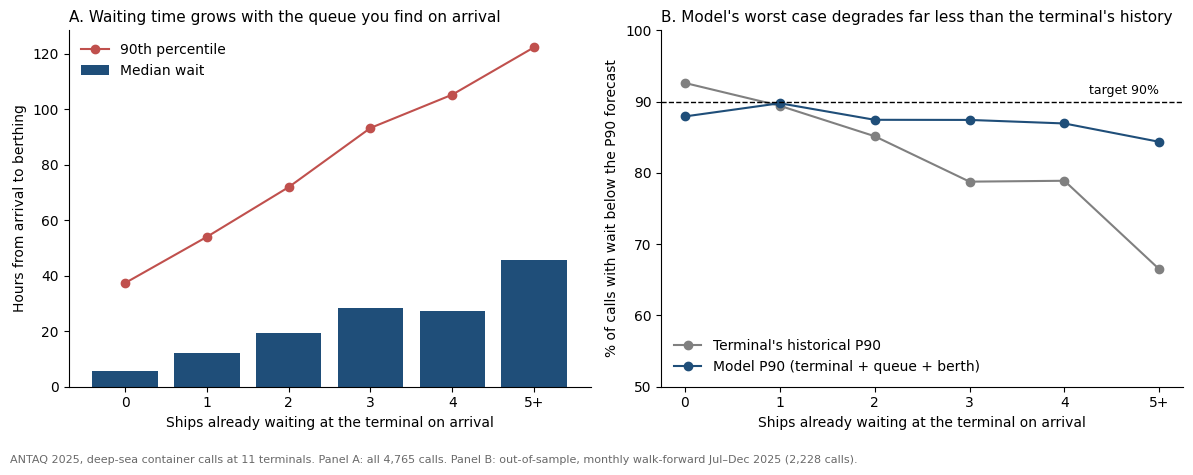

In [16]:
# 16 — Figure for the README (fig08)
FIG_DIR = BASE / "outputs" / "figures"
lab = ["0", "1", "2", "3", "4", "5+"]
x = np.arange(len(lab))

dose = model_df.groupby("q_w_bin")["wait_h"].agg(med="median", p90=lambda s: s.quantile(0.9))
cobq = r90.groupby("q_w_bin").apply(lambda g: pd.Series({
    "hist": (g["wait_h"] <= g["p90_term"]).mean() * 100,
    "model": (g["wait_h"] <= g["p90_gbm"]).mean() * 100}), include_groups=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.bar(x, dose["med"], color="#1f4e79", label="Median wait")
ax1.plot(x, dose["p90"], "o-", color="#c0504d", label="90th percentile")
ax1.set_xticks(x, lab)
ax1.set_xlabel("Ships already waiting at the terminal on arrival")
ax1.set_ylabel("Hours from arrival to berthing")
ax1.set_title("A. Waiting time grows with the queue you find on arrival", loc="left", fontsize=11)
ax1.legend(frameon=False)

ax2.plot(x, cobq["hist"], "o-", color="grey", label="Terminal's historical P90")
ax2.plot(x, cobq["model"], "o-", color="#1f4e79", label="Model P90 (terminal + queue + berth)")
ax2.axhline(90, ls="--", lw=1, color="black")
ax2.text(len(lab) - 1, 91, "target 90%", ha="right", fontsize=9)
ax2.set_xticks(x, lab)
ax2.set_ylim(50, 100)
ax2.set_xlabel("Ships already waiting at the terminal on arrival")
ax2.set_ylabel("% of calls with wait below the P90 forecast")
ax2.set_title("B. Model's worst case degrades far less than the terminal's history", loc="left", fontsize=11)
ax2.legend(frameon=False, loc="lower left")

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.01, -0.04, "ANTAQ 2025, deep-sea container calls at 11 terminals. "
         "Panel A: all 4,765 calls. Panel B: out-of-sample, monthly walk-forward Jul–Dec 2025 (2,228 calls).",
         fontsize=8, color="dimgrey")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig08_wait_model.png", dpi=150, bbox_inches="tight")
plt.show()

## Results

| Model | MAE | Median abs. error | MAE on waits > 48h |
|---|---|---|---|
| B0 terminal median | 25.7h | 13.3h | 76.9h |
| B1 30-day rolling median | 24.9h | 14.5h | 66.8h |
| B2 lookup table (terminal x queue x berth) | 23.9h | 12.3h | 68.8h |
| **Model (terminal + queue + berth)** | **23.1h** | **11.6h** | **66.5h** |
| Same model, 48h before arrival | 25.0h | 12.5h | 73.5h |

- The model beats the 30-day rolling median by about 1.8 hours per call (95% CI roughly 1.3 to 2.3), in all six test months. The result holds with a 30-day plausibility cap. TEU per call adds nothing.
- What drives the forecast is how many ships are ahead of you when you arrive, not the terminal's recent average.
- The P90 forecast is the more useful output. With five or more ships waiting, the terminal's historical P90 is exceeded in one call out of three; the model's is exceeded in about one out of six.

## Limitations

1. **It works on arrival, not before.** Measured 48 hours earlier, the queue loses most of its signal and the model no longer beats the baseline. Most ships in the queue on arrival had not arrived yet two days earlier. Speed decisions would need expected arrivals (AIS or ETAs), which public ANTAQ data does not have and carriers do.
2. **It does not anticipate congestion.** On waits above 48 hours the gain is not statistically significant.
3. **The P90 runs slightly low.** Actual coverage is about 88%, not 90%. A conformal adjustment on recent residuals would fix it; not done here.
4. **One year of data.** No check on another year, and no way to separate the model learning from the second-half regime change.
5. **Confidence intervals are optimistic.** Weeks are resampled as blocks, but consecutive weeks are still correlated.
6. **The queue counts container ships only, per terminal.** Other ship types at multipurpose berths (Paranaguá public quay) and shared channel access in Santos are not captured.